## **Wealth Management engineering**
    WELSCH Nathan & TARILLON-KIEFFER Liam

**Project Objective:** To optimize an investment portfolio using modern portfolio theory (MPT) and Markowitz's algorithm.

Calculate the optimal asset allocation to maximize the Sharpe ratio using real-time market data.

**Investment Policy Statement (IPS)**

1. Investor Profile The investor is an informed private investor with a long-term investment horizon. They seek to grow their capital while maintaining a controlled level of risk, compatible with exposure to financial markets.

2. Investment Objectives The investor's primary objective is to maximize the risk-adjusted performance of their portfolio. The target annual return is set around 6%, with the ambition to outperform the risk-free rate and generate stable value creation over the long term.

3. Investment Horizon The investment horizon is estimated between 10 and 15 years. Short-term liquidity needs are low, and an annual rebalancing of the portfolio is planned to maintain the target allocation.

4. Risk Tolerance The investor accepts a high exposure to equity risk, while seeking to diversify systemic risk through an allocation to gold. Gold is considered a safe haven, weakly correlated with equity markets and offering partial protection during periods of market stress. This exposure is however subject to the following constraints:

>Maximum annual volatility: 15%

>Maximum tolerable loss (MaxD): -25%

>Value-at-Risk at 95%: less than 10%

5. Allocation Constraints The portfolio is subject to the following constraints:

No short selling

Maximum weight per asset: 30%

Minimum weight per asset: 0%

Number of assets: between 5 and 10

Fully invested portfolio, with the sum of weights equal to 100%

6. Investment Universe The investment universe is composed exclusively of: Equities (American, European, and emerging markets) Commodities, limited to gold via ETFs Explicitly excluded from the investment universe are: Bonds, derivatives, crypto-assets

7. Benchmark Retained: The main benchmark retained is a passive portfolio composed of 80% global equities and 20% gold, represented respectively by the MSCI World index and an ETF replicating the price of gold. The weighting is assumed to be fixed and rebalanced annually, to ensure a homogeneous comparison with the optimal allocation strategy adopted. The risk-free rate used corresponds to the yield of the French 10-year government bond, set at 3.447% as of 06/02/2026.

8. Retained Allocation Method The optimal portfolio allocation is determined using a Markowitz mean-variance optimization model, integrating all constraints defined in this Investment Policy Statement.

# Librairies importation

In [38]:
import yfinance as yf
import pandas as pd
import pandas_datareader as pdr
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings
from scipy.stats import norm # Import norm for parametric VaR

## 1. Data extraction from the MSCI World Acc ETF

In [26]:
def filtrage_ETF(etf_ticker_placeholder):
    # Placeholder list of common stock tickers to simulate ETF holdings
    placeholder_tickers = ['NVDA','AAPL','MSFT','AMZN','GOOGL','GOOG','META','AVGO','TSLA','LLY','JPM','UNH','XOM','V','MA','COST','ORCL','HD','PG','NFLX','ABBV','BAC','SAP','ASML','CRM','WMT','KO','CVX','TM','ADBE','PEP','MRK','LIN','TMO','WFC','MCD','ACN','CSCO','ABT','DIS','QCOM','BAC','GE','INTU','DHR','CAT','VZ','TXN','IBM','AMAT','AXP','PFE','MS','PM','AMGN','UNH','GS','ISRG','NOW','HON','RTX','LOW','BKNG','SPGI','INTC','SYK','C','TJX','PGR','BLK','ELV','REGN','SCHW','VRTX','ETN','BSX','LMT','ADI','PANW','MDLZ','CB','CI','MMC','BA','MU','PLTR','GILD','ADP','LRCX','DE','VRT','T','WM','ADI','AMT','MDT','ZTS','ICE','SBUX','MO','ITW','MMC','SHW','ANET','CVS','HCA','BX','EQIX','ECL','PH','GD','MCK','ORLY','CDNS','BSX','MAR','NXPI','CTAS','BDX','APH','MCO','TGT','F','EMR','ADSK','ROP','TDG','KLAC','AON','CMG','PNC','TEL','MET','CARR','SNPS','EW','DASH','APO','DLR','AJG','MCHP','COF','MSI','GWW','TRV','HUM','AIG','ALL','CPRT','USB','MCK','O','STZ','MPC','KMB','VRSK','ORLY','AZO','FMS','NSC','NEM','GLW','PAYX','GEV','IT','KMI','KDP','WMB','BKR','WELL','DOW','A','PRU','STT','OTIS','FAST','KR','CEG','ODFL','CTVA','ED','VICI','BBY','EIX','HPQ','TEL','DD','HAL','VLO','OKE','TRGP','MTD','KEYS','K','FITB','EFX','EBAY','WST','WDC','ROK','GPN','FICO','ZBRA','TER','ALGN','VTR','AVB','EQR','ARE','INVH','SBAC','EXR','MAA','CPT','BXP','UDR','DOC','REG','KIM','FRT','HST','O','STAG','NNN','WPC','ADC','PLD','SPG']
    print(f"Analyzing simulated holdings for ETF: {etf_ticker_placeholder}")
    print(f"Tickers to analyze: {placeholder_tickers}")

    # Define date range for 5 years of historical data
    endDate = dt.datetime.now()
    startDate = endDate - dt.timedelta(days=365 * 5) # 5 years

    # Download adjusted close prices for all placeholder tickers
    # Explicitly set auto_adjust=False to ensure 'Adj Close' column is present
    data = yf.download(placeholder_tickers, start=startDate, end=endDate, auto_adjust=False)['Adj Close']
    print(f"Downloaded historical data for {len(placeholder_tickers)} tickers from {startDate.strftime('%Y-%m-%d')} to {endDate.strftime('%Y-%m-%d')}.")

    # Calculate daily log returns
    log_returns = np.log(data / data.shift(1)).dropna()
    print(f"Calculated daily log returns for {log_returns.shape[1]} tickers. Shape: {log_returns.shape}")

    # Define the risk-free rate
    rf = 0.03447

    # Calculate annualized mean returns
    annual_mean_returns = log_returns.mean() * 252

    # Calculate annualized standard deviation (volatility)
    annual_std_dev = log_returns.std() * np.sqrt(252)

    # Calculate Sharpe ratio for each stock
    sharpe_ratios = (annual_mean_returns - rf) / annual_std_dev

    print(f"Calculated Sharpe ratios for {len(sharpe_ratios)} tickers.")

    # Sort Sharpe ratios in descending order and get the top 10 tickers and their values
    top_10_sharpe_info = sharpe_ratios.nlargest(10)
    print(f"Top 10 tickers based on Sharpe Ratio:\n{top_10_sharpe_info}")

    return top_10_sharpe_info

We only extract the company which weight more than 0.8% of the index in order to have a significant impact on the future allocation

In [35]:
top_sharpe_stocks = filtrage_ETF("Amundi Core MSCI World UCITS ETF Acc")

Analyzing simulated holdings for ETF: Amundi Core MSCI World UCITS ETF Acc
Tickers to analyze: ['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'GOOG', 'META', 'AVGO', 'TSLA', 'LLY', 'JPM', 'UNH', 'XOM', 'V', 'MA', 'COST', 'ORCL', 'HD', 'PG', 'NFLX', 'ABBV', 'BAC', 'SAP', 'ASML', 'CRM', 'WMT', 'KO', 'CVX', 'TM', 'ADBE', 'PEP', 'MRK', 'LIN', 'TMO', 'WFC', 'MCD', 'ACN', 'CSCO', 'ABT', 'DIS', 'QCOM', 'BAC', 'GE', 'INTU', 'DHR', 'CAT', 'VZ', 'TXN', 'IBM', 'AMAT', 'AXP', 'PFE', 'MS', 'PM', 'AMGN', 'UNH', 'GS', 'ISRG', 'NOW', 'HON', 'RTX', 'LOW', 'BKNG', 'SPGI', 'INTC', 'SYK', 'C', 'TJX', 'PGR', 'BLK', 'ELV', 'REGN', 'SCHW', 'VRTX', 'ETN', 'BSX', 'LMT', 'ADI', 'PANW', 'MDLZ', 'CB', 'CI', 'MMC', 'BA', 'MU', 'PLTR', 'GILD', 'ADP', 'LRCX', 'DE', 'VRT', 'T', 'WM', 'ADI', 'AMT', 'MDT', 'ZTS', 'ICE', 'SBUX', 'MO', 'ITW', 'MMC', 'SHW', 'ANET', 'CVS', 'HCA', 'BX', 'EQIX', 'ECL', 'PH', 'GD', 'MCK', 'ORLY', 'CDNS', 'BSX', 'MAR', 'NXPI', 'CTAS', 'BDX', 'APH', 'MCO', 'TGT', 'F', 'EMR', 'ADSK', 'ROP', 'TDG', 'K

[*********************100%***********************]  219 of 219 completed


Downloaded historical data for 228 tickers from 2021-02-11 to 2026-02-10.
Calculated daily log returns for 219 tickers. Shape: (428, 219)
Calculated Sharpe ratios for 219 tickers.
Top 10 tickers based on Sharpe Ratio:
Ticker
WELL    2.044191
GLW     1.865407
PLTR    1.843065
GEV     1.793056
VTR     1.607284
WMT     1.511344
GS      1.466808
WDC     1.464048
APH     1.461675
NEM     1.445330
dtype: float64


##2. Dynamic Dashboard construction

In [40]:
#Annualized volatility
def standard_dev(weights, cov_matrix):
  variance=weights.T @ cov_matrix @ weights #multiplying a matrix with weight ponderation
  return np.sqrt(variance)

In [41]:
#Annualized return
def expected_returns(weights,log_returns):
  return np.sum(log_returns.mean()*weights)*252

In [42]:
#Sharpe Ratio
def Sharpe_ratio(weights,log_returns,cov_matrix,rf):
  return (expected_returns(weights,log_returns)-rf)/standard_dev(weights,cov_matrix)

In [48]:
#Value at Risk
def plot_var_distribution(returns_dollar, VaR, confidence_interval, days, title):
  plt.hist(returns_dollar.dropna(), bins=50, color='skyblue', edgecolor='black', density=True)
  plt.xlabel(f'{days}- Day Portfolio Return (Dollar Value)')
  plt.ylabel('Frequency')
  plt.title(title)
  plt.axvline(x=-VaR, color='red', linestyle='--', label=f'VaR {confidence_interval*100}%')
  plt.legend()
  plt.show()

def Value_at_risk(returns_percentage, confidence_interval, portfolio_value):
  # Calculate VaR based on historical returns (percentage)
  # For example, using the percentile method
  return -np.percentile(returns_percentage, (1 - confidence_interval) * 100) * portfolio_value

  def VaR_parametric_constraint_func(weights, log_returns, confidence_interval, days):
    # Calculate portfolio daily mean return
    portfolio_mean_daily_return = np.sum(log_returns.mean() * weights)

    # Calculate portfolio daily standard deviation

    portfolio_daily_std_dev = np.sqrt(np.dot(weights.T, np.dot(log_returns.cov(), weights))) # This should use daily cov, not annualized

    # Calculate VaR for 'days' period

    alpha = 1 - confidence_interval
    z_score = norm.ppf(alpha)

    VaR_percent = -(portfolio_mean_daily_return * days + z_score * portfolio_daily_std_dev * np.sqrt(days))
    return VaR_percent

In [44]:
#Max drawdown

def summarize_max_drawdown(cumulative_returns):
    # Calculate the running maximum (peak) of the cumulative returns
    running_max = cumulative_returns.expanding(min_periods=1).max()

    # Calculate the drawdown
    drawdown = (cumulative_returns - running_max) / running_max

    # Calculate the maximum drawdown
    max_drawdown = drawdown.min()

    print(f"  Maximum Drawdown: {max_drawdown:.4f}")
    return max_drawdown

In [52]:
#Calculation of Skewness & Kurtosis

def summarize_distribution_moments(optimal_returns, equal_returns):
    print("Optimal Portfolio:")
    print(f"  Skewness: {optimal_returns.skew():.4f}")
    print(f"  Kurtosis: {optimal_returns.kurt():.4f}")

    print("\nEqually Weighted Portfolio:")
    print(f"  Skewness: {equal_returns.skew():.4f}")
    print(f"  Kurtosis: {equal_returns.kurt():.4f}")

In [ ]:
def summarize_all_portfolio_analysis(tickers):
    # Suppress FutureWarning from yfinance
    warnings.filterwarnings('ignore', category=FutureWarning)

    # Defining the date range
    endDate = dt.datetime.now()
    startDate = endDate - dt.timedelta(days=365 * 5)

    # Fixed factors, updated to match IPS
    rf = 0.03447  # Updated to match IPS: 3.447%
    confidence_interval = 0.95  # Updated to match IPS: 95% for VaR
    portfolio_value = 10000
    days = 5
    num_simulations = 1000
    num_days = 252

    # Download close prices
    close_df = pd.DataFrame()
    for ticker in tickers:
        data = yf.download(ticker, start=startDate, end=endDate, progress=False, auto_adjust=False)
        close_df[ticker] = data['Adj Close']

    # Calculate log returns
    log_returns = np.log(close_df / close_df.shift(1)).dropna()

    # Calculate covariance matrix for optimization
    cov_matrix_opt = log_returns.cov() * 252 # Annualized covariance

    # Constraints and bounds for optimization, updated to match IPS
    # Poids maximum par actif : 30 % -> upper bound 0.30
    # Poids minimum par actif : 0% -> lower bound 0
    bounds = [(0.0, 0.30) for _ in range(len(tickers))]

    # Define constraints list
    constraints = [
        {'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1}, # Sum of weights = 1

        # Volatility constraint: Annual Volatility <= 0.15
        {'type': 'ineq', 'fun': lambda weights: 0.15 - standard_dev(weights, cov_matrix_opt)},

        # Parametric VaR constraint: VaR (percentage) <= 0.10 (10%)
        {'type': 'ineq', 'fun': lambda weights: 0.10 - VaR_parametric_constraint_func(weights, log_returns, confidence_interval, days)}
    ]

    # Initial weights
    initial_weights = np.array([1 / len(tickers) for _ in range(len(tickers))])

    # Optimize the weights
    optimized_results = minimize(lambda weights: -Sharpe_ratio(weights, log_returns, cov_matrix_opt, rf),
                                 initial_weights, method='SLSQP', bounds=bounds, constraints=constraints)
    print("--- Optimal weights ---")

    optimal_weights = optimized_results.x

    optimal_portfolio_returns = expected_returns(optimal_weights, log_returns)
    optimal_portfolio_std = standard_dev(optimal_weights, cov_matrix_opt)
    optimal_sharpe_ratio = Sharpe_ratio(optimal_weights, log_returns, cov_matrix_opt, rf)

    print("Optimal Weights:")
    for ticker, weight in zip(tickers, optimal_weights):
        print(f"{ticker}: {weight:.4f}")

    print(f"\nExpected Returns: {optimal_portfolio_returns:.4f}")
    print(f"Standard Deviation: {optimal_portfolio_std:.4f}")
    print(f"Sharpe Ratio: {optimal_sharpe_ratio:.4f}")

    print("\n--- IPS Constraint Checks for Optimal Portfolio ---")

    # 1. Volatility Constraint Check
    volatility_limit = 0.15
    print(f"Annual Volatility (Target max {volatility_limit*100:.0f}%) : {optimal_portfolio_std*100:.2f}%")
    if optimal_portfolio_std < volatility_limit:
        print("  Status: Respected")
    else:
        print("  Status: Violated")

    # Calculate number of assets
    num_assets = len(tickers)

    # Create an equal_weights NumPy array
    equal_weights = np.array([1/num_assets for _ in range(num_assets)])

    # Calculate expected returns for equally weighted portfolio
    equal_weighted_returns = expected_returns(equal_weights, log_returns)

    print("\n--- Expected Returns results ---")

    print(f"\nExpected Returns (Optimal Portfolio): {optimal_portfolio_returns:.4f}")
    print(f"Expected Returns (Equally Weighted Portfolio): {equal_weighted_returns:.4f}")

    print("\n--- Historical VaR Analysis ---")
    # Call summarize_historical_var
    def summarize_historical_var_updated(log_returns, optimal_weights, equal_weights, confidence_interval, portfolio_value, days):
        historical_optimal_returns = (log_returns * optimal_weights).sum(axis=1)
        range_optimal_returns = historical_optimal_returns.rolling(window=days).sum().dropna()
        range_optimal_returns_dollar = range_optimal_returns * portfolio_value

        historical_equal_returns = (log_returns * equal_weights).sum(axis=1)
        range_equal_returns = historical_equal_returns.rolling(window=days).sum().dropna()
        range_equal_returns_dollar = range_equal_returns * portfolio_value

        VaR_optimized = Value_at_risk(range_optimal_returns, confidence_interval, portfolio_value)
        VaR_equally_weighted = Value_at_risk(range_equal_returns, confidence_interval, portfolio_value)

        print(f"VaR for Optimal Portfolio: -${VaR_optimized:.2f}")
        print(f"VaR for Equally Weighted Portfolio: -${VaR_equally_weighted:.2f}")

        plot_var_distribution(range_optimal_returns_dollar, VaR_optimized, confidence_interval, days, f'Distribution of Optimized Portfolio {days}-Day Returns (Dollar Value)')
        plot_var_distribution(range_equal_returns_dollar, VaR_equally_weighted, confidence_interval, days, f'Distribution of Equally Weighted Portfolio {days}-Day Returns (Dollar Value)')

        return VaR_optimized, VaR_equally_weighted, historical_optimal_returns, historical_equal_returns

    VaR_optimal, VaR_equal, historical_optimal_returns, historical_equal_returns = \
        summarize_historical_var_updated(log_returns, optimal_weights, equal_weights, confidence_interval, portfolio_value, days)

    # 3. Value at Risk Constraint Check (Historical VaR for consistency with previous checks)
    VaR_limit_percentage = 0.10
    VaR_percentage_optimal = VaR_optimal / portfolio_value
    print(f"Value at Risk (Target max {VaR_limit_percentage*100:.0f}%) : {VaR_percentage_optimal*100:.2f}%")
    if VaR_percentage_optimal < VaR_limit_percentage:
        print("  Status: Respected")
    else:
        print("  Status: Violated")


    print("\n--- Maximum Drawdown Analysis ---")

    cumulative_optimal_returns = historical_optimal_returns.cumsum()
    print("Optimal Portfolio:")
    # Calculate max drawdown for optimal portfolio here to check constraint
    max_drawdown_optimal = summarize_max_drawdown(cumulative_optimal_returns)
    # 2. Maximum Drawdown Constraint Check
    max_drawdown_limit = -0.25
    print(f"Maximum Drawdown (Target max {max_drawdown_limit*100:.0f}%) : {max_drawdown_optimal*100:.2f}%")
    if max_drawdown_optimal > max_drawdown_limit: # Max drawdown is a negative value, so ">" means less severe loss
        print("  Status: Respected")
    else:
        print("  Status: Violated")

    cumulative_equal_returns = historical_equal_returns.cumsum()
    print("Equally Weighted Portfolio:")
    summarize_max_drawdown(cumulative_equal_returns) # This will print max drawdown for equal portfolio

    print("\n--- Distribution Moments ---")
    summarize_distribution_moments(historical_optimal_returns, historical_equal_returns)

    # --- Benchmark Portfolio Calculation ---
    print("\n--- Benchmark Portfolio Analysis ---")
    benchmark_tickers = ['IWDA.AS', 'GLD']
    benchmark_weights = {'IWDA.AS': 0.8, 'GLD': 0.2}

    benchmark_close_df = pd.DataFrame()
    for ticker in benchmark_tickers:
        data = yf.download(ticker, start=startDate, end=endDate, progress=False, auto_adjust=False)
        benchmark_close_df[ticker] = data['Adj Close']

    benchmark_log_returns = np.log(benchmark_close_df / benchmark_close_df.shift(1)).dropna()

    # Align benchmark returns with the existing log_returns index
    common_index = log_returns.index.intersection(benchmark_log_returns.index)
    aligned_benchmark_log_returns = benchmark_log_returns.reindex(common_index)

    # Calculate historical weighted returns for the benchmark
    historical_benchmark_returns = (
        aligned_benchmark_log_returns['IWDA.AS'] * benchmark_weights['IWDA.AS']
    ) + (
        aligned_benchmark_log_returns['GLD'] * benchmark_weights['GLD']
    )

    cumulative_benchmark_returns = historical_benchmark_returns.cumsum()
    print(f"Cumulative returns for Benchmark Portfolio (80% MSCI World, 20% Gold):\n{cumulative_benchmark_returns.iloc[-1]:.4f}")


    # --- Plotting Cumulative Returns ---
    plt.figure(figsize=(12, 6))
    plt.plot(cumulative_optimal_returns.index, cumulative_optimal_returns, label='Optimal Portfolio Cumulative Returns', color='blue')
    plt.plot(cumulative_equal_returns.index, cumulative_equal_returns, label='Equally Weighted Portfolio Cumulative Returns', color='green')
    plt.plot(cumulative_benchmark_returns.index, cumulative_benchmark_returns, label='Benchmark Portfolio Cumulative Returns (80% IWDA.AS, 20% GLD)', color='red')
    plt.title('Cumulative Returns Comparison')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Log Returns')
    plt.legend()
    plt.grid(True)
    plt.show()

    print("\n--- Monte Carlo Simulation ---")

    # Calculate mean daily returns and covariance matrix for MC
    mean_daily_returns = log_returns.mean()
    cov_matrix_mc = log_returns.cov()

    # Cholesky decomposition of the covariance matrix
    L = np.linalg.cholesky(cov_matrix_mc)

    plt.figure(figsize=(15, 7))

    # --- Optimal Portfolio Simulation ---
    simulated_optimal_portfolio_values = np.zeros((num_days, num_simulations))
    for s in range(num_simulations):
        daily_returns_optimal = np.zeros((num_days, num_assets))
        for day in range(num_days):
            # Generate random correlated returns
            random_vec = np.random.normal(size=num_assets)
            correlated_returns = mean_daily_returns + np.dot(L, random_vec)
            daily_returns_optimal[day, :] = correlated_returns

        portfolio_daily_returns_optimal = np.dot(daily_returns_optimal, optimal_weights)
        simulated_optimal_portfolio_values[:, s] = portfolio_value * np.exp(np.cumsum(portfolio_daily_returns_optimal))

    plt.subplot(1, 2, 1)
    plt.plot(simulated_optimal_portfolio_values)
    plt.title(f'Optimal Portfolio Monte Carlo Simulation ({num_simulations} runs)')
    plt.xlabel('Days')
    plt.ylabel('Portfolio Value')
    plt.grid(True)

    # --- Equally Weighted Portfolio Simulation ---
    simulated_equal_portfolio_values = np.zeros((num_days, num_simulations))
    for s in range(num_simulations):
        daily_returns_equal = np.zeros((num_days, num_assets))
        for day in range(num_days):
            # Generate random correlated returns
            random_vec = np.random.normal(size=num_assets)
            correlated_returns = mean_daily_returns + np.dot(L, random_vec)
            daily_returns_equal[day, :] = correlated_returns

        # Corrected line: portfolio_daily_returns_equal should be calculated from daily_returns_equal
        portfolio_daily_returns_equal = np.dot(daily_returns_equal, equal_weights)
        simulated_equal_portfolio_values[:, s] = portfolio_value * np.exp(np.cumsum(portfolio_daily_returns_equal))

    plt.subplot(1, 2, 2)
    plt.plot(simulated_equal_portfolio_values)
    plt.title(f'Equally Weighted Portfolio Monte Carlo Simulation ({num_simulations} runs)')
    plt.xlabel('Days')
    plt.ylabel('Portfolio Value')
    plt.grid(True)

    plt.tight_layout()
    plt.show()


    # --- Summary Statistics for Final Portfolio Values ---
    final_optimal_values = simulated_optimal_portfolio_values[-1, :]
    final_equal_values = simulated_equal_portfolio_values[-1, :]

    print("\n--- Summary Statistics for Final Portfolio Values ---")
    print("Optimal Portfolio:")
    print(f"  Mean: ${np.mean(final_optimal_values):.2f}")
    print(f"  Median: ${np.median(final_optimal_values):.2f}")
    print(f"  Standard Deviation: ${np.std(final_optimal_values):.2f}")
    print(f"  Minimum: ${np.min(final_optimal_values):.2f}")
    print(f"  Maximum: ${np.max(final_optimal_values):.2f}")

    print("\nEqually Weighted Portfolio:")
    print(f"  Mean: ${np.mean(final_equal_values):.2f}")
    print(f"  Median: ${np.median(final_equal_values):.2f}")
    print(f"  Standard Deviation: ${np.std(final_equal_values):.2f}")
    print(f"  Minimum: ${np.min(final_equal_values):.2f}")
    print(f"  Maximum: ${np.max(final_equal_values):.2f}")

    print("\n--- Comprehensive Portfolio Analysis Complete ---")

tickers_for_analysis = top_sharpe_stocks.index.tolist() + ['GLD']
summarize_all_portfolio_analysis(tickers_for_analysis)

--- Optimal weights ---
Optimal Weights:
WELL: 0.2320
GLW: 0.1427
PLTR: 0.0192
GEV: 0.0556
VTR: 0.0693
WMT: 0.1704
GS: 0.0000
WDC: 0.0108
APH: 0.0000
NEM: 0.0000
GLD: 0.3000

Expected Returns: 0.5182
Standard Deviation: 0.1466
Sharpe Ratio: 3.3005

--- IPS Constraint Checks for Optimal Portfolio ---
Annual Volatility (Target max 15%) : 14.66%
  Status: Respected

--- Expected Returns results ---

Expected Returns (Optimal Portfolio): 0.5182
Expected Returns (Equally Weighted Portfolio): 0.6269

--- Historical VaR Analysis ---
VaR for Optimal Portfolio: -$196.15
VaR for Equally Weighted Portfolio: -$370.53


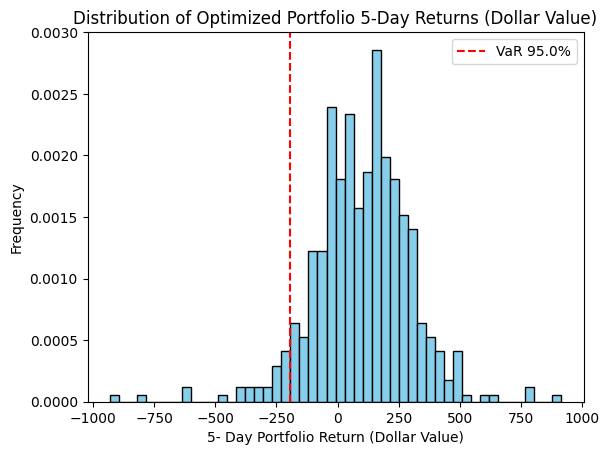

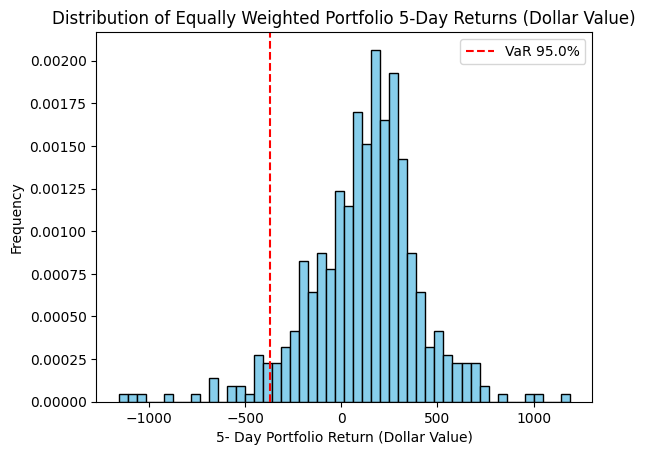

Value at Risk (Target max 10%) : 1.96%
  Status: Respected

--- Maximum Drawdown Analysis ---
Optimal Portfolio:
  Maximum Drawdown: -1.7157
Maximum Drawdown (Target max -25%) : -171.57%
  Status: Violated
Equally Weighted Portfolio:
  Maximum Drawdown: -2.0733

--- Distribution Moments ---
Optimal Portfolio:
  Skewness: 0.0077
  Kurtosis: 7.5827

Equally Weighted Portfolio:
  Skewness: -0.2577
  Kurtosis: 7.0933

--- Benchmark Portfolio Analysis ---
Cumulative returns for Benchmark Portfolio (80% MSCI World, 20% Gold):
0.3289


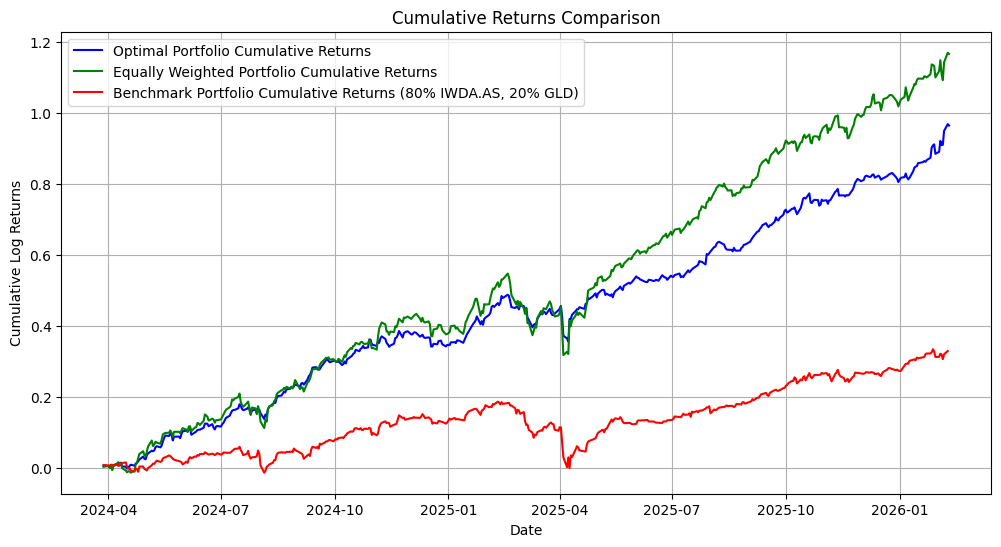


--- Monte Carlo Simulation ---


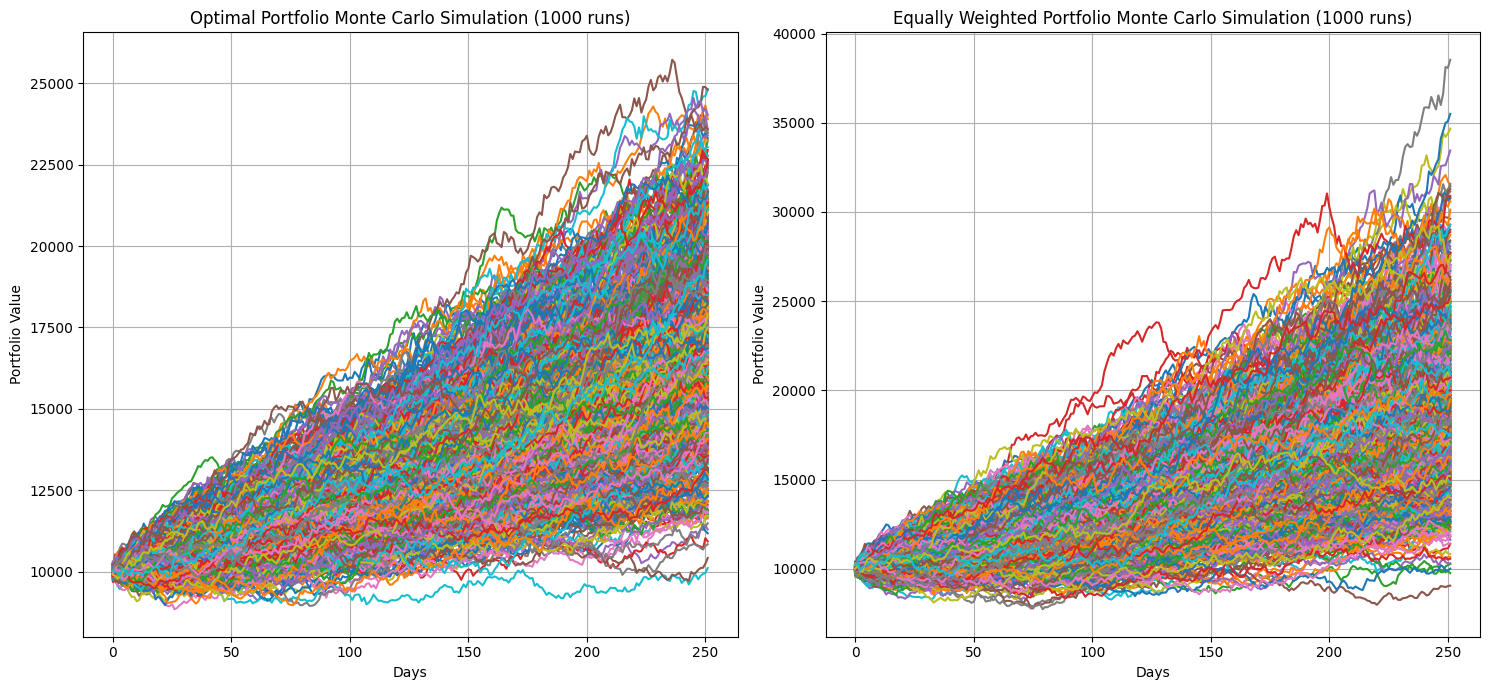


--- Summary Statistics for Final Portfolio Values ---
Optimal Portfolio:
  Mean: $16879.88
  Median: $16681.22
  Standard Deviation: $2516.61
  Minimum: $10107.26
  Maximum: $24819.87

Equally Weighted Portfolio:
  Mean: $19207.64
  Median: $18690.75
  Standard Deviation: $4132.71
  Minimum: $9050.57
  Maximum: $38532.24

--- Comprehensive Portfolio Analysis Complete ---


In [56]:
tickers_for_analysis = top_sharpe_stocks.index.tolist() + ['GLD']
summarize_all_portfolio_analysis(tickers_for_analysis)

Now that we've obtained a dashboard which consist of analyzing two different parameter of wealth management : equally weighted capital and optimally allocated wealth.
Then we define each metrics for each allocation, then the different risk metrics in order to visualize the loss and the risk we occurs using each strategy.
In the last part, in order to outline our strategies in the future, we use a Monte-Carlo simulation to draws perspectives of which portfolio would outperform in the next year.
Finally, we plot a graph which shows us the evolution of the 2 portfolios and the benchmark defined in the IPS.